In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors,datasets

In [18]:
#导入并整理数据
iris = datasets.load_iris()
X = iris.data[:,:2]
#提取分类标签
y = iris.target

In [20]:
#创建了预测分类的查询点
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1,xx2 = np.meshgrid(x1_array,x2_array)

In [24]:
#创建色谱
rgb = [[255,238,255],
       [219,238,244],
       [228,228,228]]
#转换为0-1的浮点数,带.表示浮点数
rgb = np.array(rgb)/255.
#创建离散色谱 ,可视化为区域背景色
#提供颜色映射表,根据分类和数值填充颜色区域,数值必须与颜色对应,自动填充
#再绘图阶段,matplotlib这里支持使用Z的索引取得的数字值对应cmap导入的色谱实参进行生成颜色二维表格用于渲染
cmap_light = ListedColormap(rgb)
cmap_bold = [[255,51,0],
             [0,153,255],
             [138,138,138]]
#强调色,直接用于点的原色选取,不需要映射整张区域
#是一个numpy数组,不是colormap对象
cmap_bold = np.array(cmap_bold)/255.

In [40]:
k_neighbors = 4#临近数量为4
#创建分类器对象kNN 指定了算法使用最近邻居数量
kNN = neighbors.KNeighborsClassifier(k_neighbors)
kNN.fit(X,y)

KNeighborsClassifier(n_neighbors=4)

In [42]:
#内部展平成一维数组,然后按列合并 形状为n行2列
q = np.c_[xx1.ravel(),xx2.ravel()]
#用knn对一系列查询点进行预测
y_predict = kNN.predict(q)
#再将形状恢复为二维数组
y_predict = y_predict.reshape(xx1.shape)

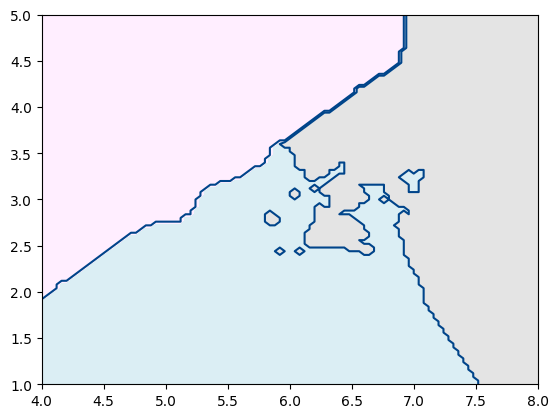

In [46]:
#可视化
fig,ax = plt.subplots()
#函数名中的f表示filled满的)
plt.contourf(xx1,xx2,y_predict,cmap = cmap_light)
plt.contour(xx1,xx2,y_predict,levels = [0,1,2],
            colors = np.array([0,68,138])/255.)
sns.scatterplot(x = X[:,0],y = X[:,1],
                hue = iris.target_names[y],
                ax = ax,
                palette = dict(setosa = cmap_bold[0,:],
                               versicolor = cmap_bold[